# MULTIPLE LINEAR REGRESSION CODING

- Multiple Linear Regression is an algorithm that predicts a continuous value using two or more input variables.

- For example, if we want to predict the student's marks based on study hours, it can also influence other factors like attendance and assignments completed and etc., So here multiple factors are used to predict student marks.

PROBLEM STATEMENT

- Predict Product sales based on ads Spent

Step: 1- Importing necessary libraries

In [2]:
# Data Handling

import pandas as pd    # For data handling and analysis
import numpy as np     # For numerical operation

In [3]:
# Data Visualization

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Machine learning algorithm and utilities

from sklearn.linear_model import LinearRegression    # importing linear regression algorithm
from sklearn.model_selection import train_test_split  # Splitting dataset for training and testing

In [5]:
# Evaluation Matrix

from sklearn.metrics import mean_absolute_error, r2_score     #Evaluation matrix for regression

Step: 2 - Loading the Dataset

In [6]:
data_url = '/content/drive/MyDrive/Linear_Regression/Advertising.csv'     #Dataset locataion

data = pd.read_csv(data_url, index_col=0)                                 # Reading from CSV. index_col- index starting loc

data.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


Top 5 records of each ads spent value in TV, Radio and Newspaper and total sales data.

Step: 3- Summarizing the Dataset

In [7]:
data.head(10)   # Printing Top 10 records

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9
6,8.7,48.9,75.0,7.2
7,57.5,32.8,23.5,11.8
8,120.2,19.6,11.6,13.2
9,8.6,2.1,1.0,4.8
10,199.8,2.6,21.2,10.6


In [8]:
data.tail()     # Print last 5 records

,TV,Radio,Newspaper,Sales
196,38.2,3.7,13.8,7.6
197,94.2,4.9,8.1,9.7
198,177.0,9.3,6.4,12.8
199,283.6,42.0,66.2,25.5
200,232.1,8.6,8.7,13.4


In [9]:
data.info()      # Information about the dataset

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 7.8 KB


- There are 200 records which has 200 rows and 4 columns.
- There are no null values.
- All numerical columns, no categorical data
- The dataset consumes 7.8 KB of memory.  

In [10]:
data.describe()    # Print statistical summary of dataset

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


- It shows overall count, mean, Standard deviation, minimum, maximum,25%,  50%,75% distribution of data.
- Looking at the statistical summary of data, the data is evenly distributed in all four columns.  

In [11]:
data.shape  # Printing number of rows and columns

(200, 4)

Step: 4- Preprocessing the Dataset(EDA)

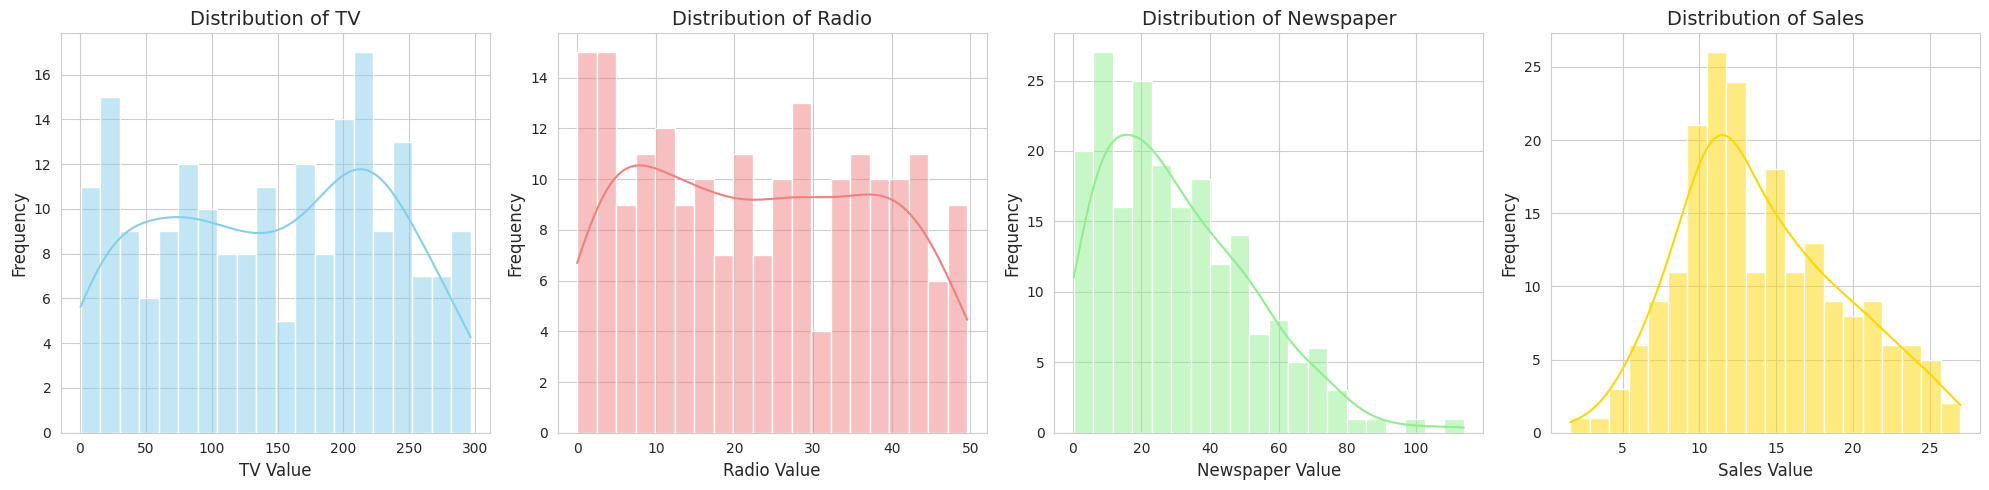

In [12]:
# Set visualization theme

sns.set_style("whitegrid")

# Distribution of each feature and the target

plt.figure(figsize=(20, 5))

features = ['TV', 'Radio', 'Newspaper', 'Sales']

colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

for i, col in enumerate(features):

    #print(i,col)

    #print('-------------')

    plt.subplot(1, 4, i + 1)

    sns.histplot(data[col], kde=True, bins=20, color=colors[i])

    plt.title(f'Distribution of {col}', fontsize=14)

    plt.xlabel(f'{col} Value', fontsize=12)

    plt.ylabel('Frequency', fontsize=12)

plt.tight_layout()

plt.show()

The histogram distribution of TV, Radio and newspaper and sales summarize the following.

1. TV - Fairly distributed from 0 to 300 budget spending. The peak spending around 200- 230. No skew is visible.

2. Radio - Evenly distributed from 0 to 50. There is no dominant spending.

3. Newspaper - It is right skewed and most advertising budgets are b/w 0 to 40. Only few observations are in high spending(80 to 100).

4. Sales- It is normally distributed(Bell shaped curve). Most sale values fall b/w 10 to 16. Peak between to 11 to 13. Higher sales occur less frequently.

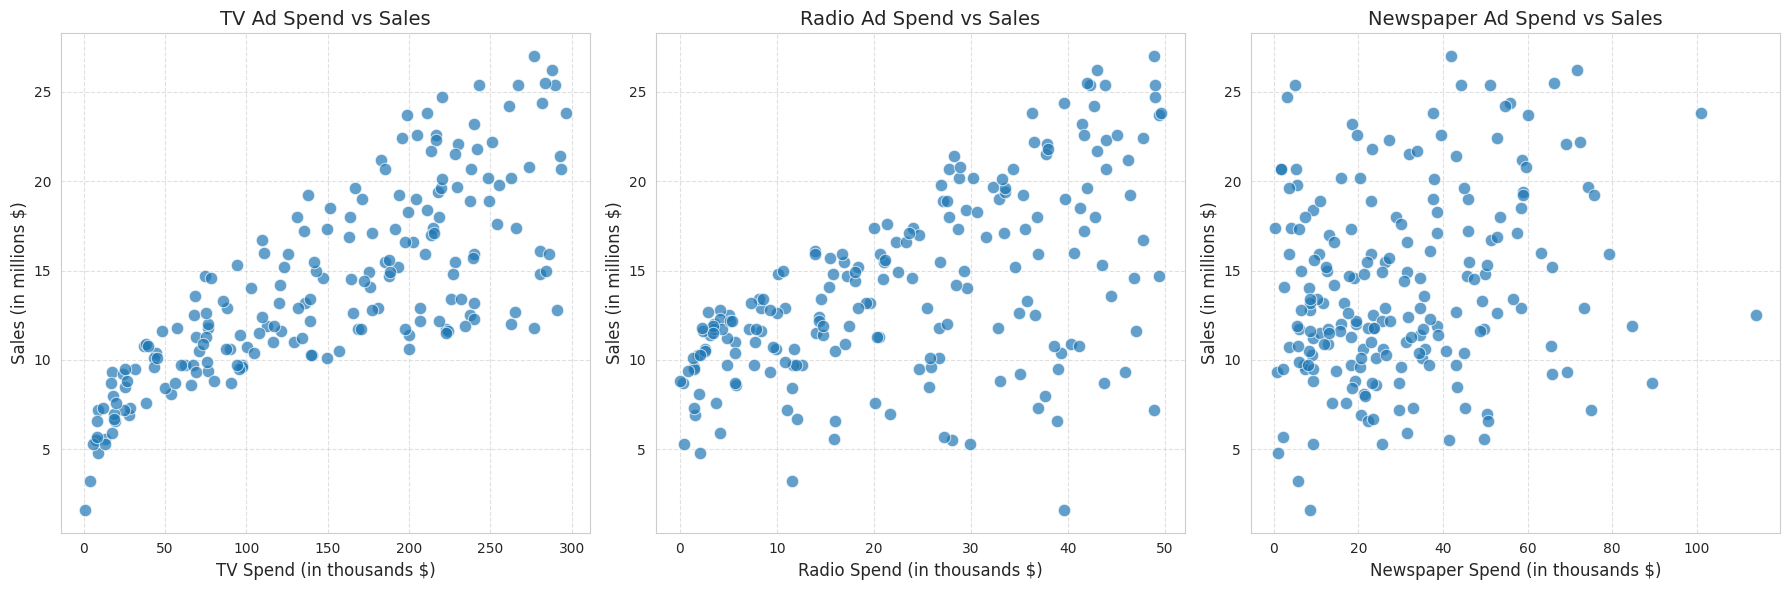

In [13]:
# Scatter plots for Sales vs Ad Spend

plt.figure(figsize=(18, 6))

for i, col in enumerate(['TV', 'Radio', 'Newspaper']):

    plt.subplot(1, 3, i + 1)

    sns.scatterplot(x=col, y='Sales', data=data, s=80, alpha=0.7)

    plt.title(f'{col} Ad Spend vs Sales', fontsize=14)

    plt.xlabel(f'{col} Spend (in thousands $)', fontsize=12)

    plt.ylabel('Sales (in millions $)', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()

plt.show()

Scatter plot shows the relationship between TV spent Vs Sales, Radio Vs Sales and Newspaper Vs sales.

1. TV - Strong positive linear relationship- TV advertising spend increases, sales generally increase. This is the strongest relationship among the three channels.

2. Radio- Moderate positive relationship- Higher radio spending is associated with higher sales, the data points are more dispersed than for TV.

3. Newspaper- No linear relationship- Newspaper spending shows less consistent pattern with sales, It shows minimum influence on sales.

Overall spending in TV advertising is giving better sales, followed by Radio. Newspaper advertising has less impact on sales. So here we will take TV ads and Radio ads spent as input variable to predict the sales.

Step: 5- Segregating the dataset into input and output

In [14]:
data['TV'].shape   # Dimension of TV data

(200,)

In [15]:
data['Radio'].shape

(200,)

In [16]:
X = data[['TV','Radio']]   # Considering TV and radio ads as inputs. converting to two dimensional since SK learn accepts 2D array.
Y = data['Sales']  # Target column

In [18]:
X.shape    # Now shape converted to two dimensions

(200, 2)

In [20]:
X    # There are two independent variable

,TV,Radio
1,230.1,37.8
2,44.5,39.3
3,17.2,45.9
4,151.5,41.3
5,180.8,10.8
...,...,...
196,38.2,3.7
197,94.2,4.9
198,177.0,9.3
199,283.6,42.0


In [21]:
Y

,Sales
1,22.1
2,10.4
3,9.3
4,18.5
5,12.9
...,...
196,7.6
197,9.7
198,12.8
199,25.5


Step: 6 - Splitting the dataset into training and testing data

In [22]:
X_train, X_test, Y_train,Y_test = train_test_split(X,Y, test_size = 0.2, random_state=42)   # Training- 80% and testing- 20%

In [23]:
X.shape ,Y.shape    # Printing the X and Y shape

((200, 2), (200,))

In [24]:
X_train.shape, X_test.shape, Y_train.shape,Y_test.shape   # Printing training and testing data of X and Y

((160, 2), (40, 2), (160,), (40,))

Step: 7 - Loading the Linear Regression Model

In [25]:
model = LinearRegression()      # Importing linear regression model. means linear equation(y= mx+c)

Step: 8 - Training the model

In [26]:
model.fit(X_train, Y_train)    # Using fit method to train the model

LinearRegression()

Step: 9 - Formulating the Linear Regression Equation

In [27]:
print('slope:', model.coef_)           # Printing slope (m)
print("Intercept:", model.intercept_)  # Printing intercept (c)

slope: [0.0447283  0.19066726]
Intercept: 3.028255250783305


Here. there are two independent variable, so two slopes m1 and m2

In [28]:
# Y = 0.0447283X1+0.19066726X2+3.028255250783305

In [29]:
# Sales = 0.0447283 x Spent on TV ads +  0.19066726 x Spent on Radio ads + 3.028255250783305

Step: 10 - Predicting the result using trained model

In [30]:
Y_pred = model.predict(X_test)         # Predict using the test data

In [31]:
Y_pred    # printing the predicted values

array([16.35747252, 20.86299397, 21.52505848, 10.58719845, 22.22459614,
       13.06070499, 21.09564403,  7.47641062, 13.62409831, 15.15019438,
        9.12761147,  6.62878923, 14.16531076,  8.97073929,  9.66825463,
       12.12821691,  8.71252199, 16.30911498, 10.26684186, 18.89010391,
       19.4519532 , 13.03925601, 12.41182149, 21.20994137,  7.88771365,
        5.80255394, 20.7764401 , 12.02358305,  9.1784369 ,  8.59012258,
       12.46070487, 10.03213267, 21.34367738, 12.11632301, 18.23376459,
       20.22242395, 14.14999367, 20.78067544, 11.07322103,  4.56335118])

In [32]:
Y_test

,Sales
96,16.9
16,22.4
31,21.4
159,7.3
129,24.7
116,12.6
70,22.3
171,8.4
175,11.5
46,14.9


Step: 11 - Calculating the loss and accuracy of the trained model

In [33]:
#accuracy

r2_score(Y_test,Y_pred)    # printing the accuracy from actual vs predicted

0.9005833101920356

In [34]:
# 0.6766954295627076 for simple linear regression with one independent variable.

- The model gives the 90% accuracy. The higher accuracy shows, more data or more features, the model can predict well and gives better output.

In [35]:
mean_absolute_error(Y_test, Y_pred)

1.4443023138227578

In [36]:
# 2.444420003751042 mse for simple linear regression with one feature.

- The mean absolute error indicates the actual vs predicted has 1 error points which is low compare when compare with simple linear regression.

Step: 12 - Visualizing the Regression Plane

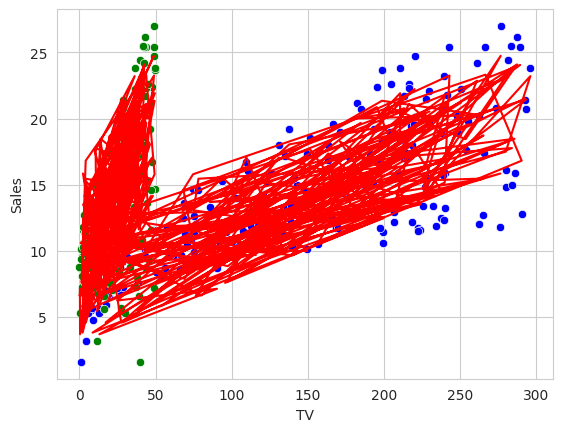

In [37]:
sns.scatterplot(x = X['TV'], y = Y, color = 'blue')   # Plot scatterplot b/w TV ads and sales
sns.scatterplot(x = X['Radio'], y = Y, color = 'green')   # Plot scatterplot b/w Radio ads and sales
plt.plot(X,model.predict(X), color= 'red')            # Draw regression Plane(Best fit line) b/w entire dataset TV & radio ads Vs predicted sales data

In [38]:
from mpl_toolkits.mplot3d import Axes3D # imports the 3D plotting toolkit from Matplotlib to enable 3D graphs.

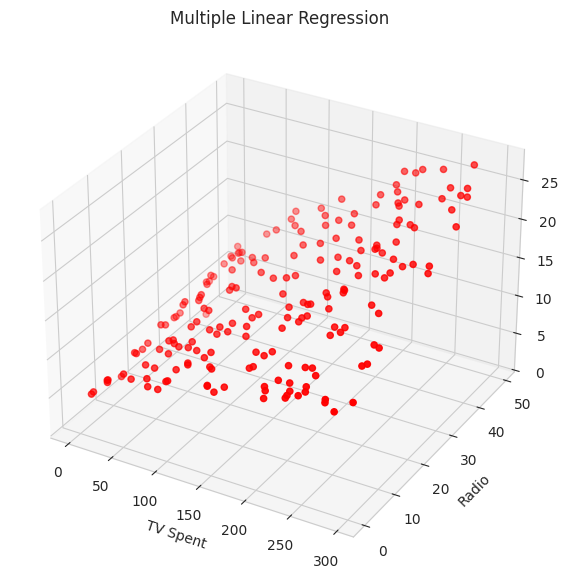

In [ ]:
fig = plt.figure(figsize=(10,7))                       # Creating a fig size
ax = fig.add_subplot(111,projection = '3d')            # Add 3D plotting area, 111->1 row, 1 column, 1 subplot and 3D axes object
ax.scatter(data['TV'],data['Radio'],Y,color = 'Red')   # Plot scatter plot X- TV, Y- Radio, Z- Sales(Y)
ax.set_xlabel('TV Spent')                              # X axis
ax.set_ylabel('Radio')                                 # Y axis
plt.title("Multiple Linear Regression")                # Title
plt.show()

Here we visualise the data points in a 3D angle. Next we need to visualize plane on this 3D object.

Next step is to prepare the X-Y coordinates where the regression plane will be drawn.

In [44]:
TV_range = np.linspace(data['TV'].min(), data['TV'].max(), 20)  # creates 20 equally spaced numbers from min to max values of TV data
Radio_range = np.linspace(data['Radio'].min(), data['Radio'].max(), 20) # creates 20 equally spaced numbers from min to max values of Radio data
print(TV_range)
print(Radio_range)


[  0.7         16.26315789  31.82631579  47.38947368  62.95263158
  78.51578947  94.07894737 109.64210526 125.20526316 140.76842105
 156.33157895 171.89473684 187.45789474 203.02105263 218.58421053
 234.14736842 249.71052632 265.27368421 280.83684211 296.4       ]
[ 0.          2.61052632  5.22105263  7.83157895 10.44210526 13.05263158
 15.66315789 18.27368421 20.88421053 23.49473684 26.10526316 28.71578947
 31.32631579 33.93684211 36.54736842 39.15789474 41.76842105 44.37894737
 46.98947368 49.6       ]


In [45]:
TV_grid, Radio_grid = np.meshgrid(TV_range,Radio_range)

This converts the two 1D arrays into a 2D grid of coordinates. The regression model then predicts the Sales value at every (TV, Radio) coordinate on that grid, allowing ax.plot_surface() to draw the regression plane.

In [49]:
len(TV_range)  # Checking the length of TV range

20

In [50]:
len(TV_grid[0])  # Checking TV grid length as same as range

20

In [51]:
TV_grid  # Print TV_grid

array([[  0.7       ,  16.26315789,  31.82631579,  47.38947368,
         62.95263158,  78.51578947,  94.07894737, 109.64210526,
        125.20526316, 140.76842105, 156.33157895, 171.89473684,
        187.45789474, 203.02105263, 218.58421053, 234.14736842,
        249.71052632, 265.27368421, 280.83684211, 296.4       ],
       [  0.7       ,  16.26315789,  31.82631579,  47.38947368,
         62.95263158,  78.51578947,  94.07894737, 109.64210526,
        125.20526316, 140.76842105, 156.33157895, 171.89473684,
        187.45789474, 203.02105263, 218.58421053, 234.14736842,
        249.71052632, 265.27368421, 280.83684211, 296.4       ],
       [  0.7       ,  16.26315789,  31.82631579,  47.38947368,
         62.95263158,  78.51578947,  94.07894737, 109.64210526,
        125.20526316, 140.76842105, 156.33157895, 171.89473684,
        187.45789474, 203.02105263, 218.58421053, 234.14736842,
        249.71052632, 265.27368421, 280.83684211, 296.4       ],
       [  0.7       ,  16.26315789,  

In [52]:
TV_grid.ravel()  # It flattens the 2D array into one long vector. LinearRegression model expect input in this form

array([  0.7       ,  16.26315789,  31.82631579,  47.38947368,
        62.95263158,  78.51578947,  94.07894737, 109.64210526,
       125.20526316, 140.76842105, 156.33157895, 171.89473684,
       187.45789474, 203.02105263, 218.58421053, 234.14736842,
       249.71052632, 265.27368421, 280.83684211, 296.4       ,
         0.7       ,  16.26315789,  31.82631579,  47.38947368,
        62.95263158,  78.51578947,  94.07894737, 109.64210526,
       125.20526316, 140.76842105, 156.33157895, 171.89473684,
       187.45789474, 203.02105263, 218.58421053, 234.14736842,
       249.71052632, 265.27368421, 280.83684211, 296.4       ,
         0.7       ,  16.26315789,  31.82631579,  47.38947368,
        62.95263158,  78.51578947,  94.07894737, 109.64210526,
       125.20526316, 140.76842105, 156.33157895, 171.89473684,
       187.45789474, 203.02105263, 218.58421053, 234.14736842,
       249.71052632, 265.27368421, 280.83684211, 296.4       ,
         0.7       ,  16.26315789,  31.82631579,  47.38

In [53]:
Radio_grid.ravel()  # Flatten radio grid also

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        2.61052632,  2.61052632,  2.61052632,  2.61052632,  2.61052632,
        2.61052632,  2.61052632,  2.61052632,  2.61052632,  2.61052632,
        2.61052632,  2.61052632,  2.61052632,  2.61052632,  2.61052632,
        2.61052632,  2.61052632,  2.61052632,  2.61052632,  2.61052632,
        5.22105263,  5.22105263,  5.22105263,  5.22105263,  5.22105263,
        5.22105263,  5.22105263,  5.22105263,  5.22105263,  5.22105263,
        5.22105263,  5.22105263,  5.22105263,  5.22105263,  5.22105263,
        5.22105263,  5.22105263,  5.22105263,  5.22105263,  5.22105263,
        7.83157895,  7.83157895,  7.83157895,  7.83157895,  7.83157895,
        7.83157895,  7.83157895,  7.83157895,  7.83157895,  7.83

In [54]:
np.c_[TV_grid.ravel(),Radio_grid.ravel()]   # combine the flattened TV and Radio arrays into a single 2D array

array([[  0.7       ,   0.        ],
       [ 16.26315789,   0.        ],
       [ 31.82631579,   0.        ],
       [ 47.38947368,   0.        ],
       [ 62.95263158,   0.        ],
       [ 78.51578947,   0.        ],
       [ 94.07894737,   0.        ],
       [109.64210526,   0.        ],
       [125.20526316,   0.        ],
       [140.76842105,   0.        ],
       [156.33157895,   0.        ],
       [171.89473684,   0.        ],
       [187.45789474,   0.        ],
       [203.02105263,   0.        ],
       [218.58421053,   0.        ],
       [234.14736842,   0.        ],
       [249.71052632,   0.        ],
       [265.27368421,   0.        ],
       [280.83684211,   0.        ],
       [296.4       ,   0.        ],
       [  0.7       ,   2.61052632],
       [ 16.26315789,   2.61052632],
       [ 31.82631579,   2.61052632],
       [ 47.38947368,   2.61052632],
       [ 62.95263158,   2.61052632],
       [ 78.51578947,   2.61052632],
       [ 94.07894737,   2.61052632],
 

In [55]:
model.predict(np.c_[TV_grid.ravel(),Radio_grid.ravel()])  # the model predicts sales from every point on the plane

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([ 3.05956506,  3.75567869,  4.45179231,  5.14790594,  5.84401957,
        6.54013319,  7.23624682,  7.93236044,  8.62847407,  9.32458769,
       10.02070132, 10.71681495, 11.41292857, 12.1090422 , 12.80515582,
       13.50126945, 14.19738308, 14.8934967 , 15.58961033, 16.28572395,
        3.55730697,  4.2534206 ,  4.94953423,  5.64564785,  6.34176148,
        7.0378751 ,  7.73398873,  8.43010235,  9.12621598,  9.82232961,
       10.51844323, 11.21455686, 11.91067048, 12.60678411, 13.30289774,
       13.99901136, 14.69512499, 15.39123861, 16.08735224, 16.78346587,
        4.05504889,  4.75116251,  5.44727614,  6.14338976,  6.83950339,
        7.53561701,  8.23173064,  8.92784427,  9.62395789, 10.32007152,
       11.01618514, 11.71229877, 12.4084124 , 13.10452602, 13.80063965,
       14.49675327, 15.1928669 , 15.88898053, 16.58509415, 17.28120778,
        4.5527908 ,  5.24890442,  5.94501805,  6.64113167,  7.3372453 ,
        8.03335893,  8.72947255,  9.42558618, 10.1216998 , 10.81

- The scatter plot already has the actual Sales values(data points).

- To draw the regression plane, Matplotlib needs the predicted Sales value at every point on the grid.

In [57]:
sample = model.predict(np.c_[TV_grid.ravel(),Radio_grid.ravel()])
sample.shape

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


(400,)

In [58]:
sample.reshape(TV_grid.shape).shape  # reshape is what reconnects the 400 individual predictions back into the 20×20 grid that represents the regression plane.

(20, 20)

Lets put all together in visualization

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


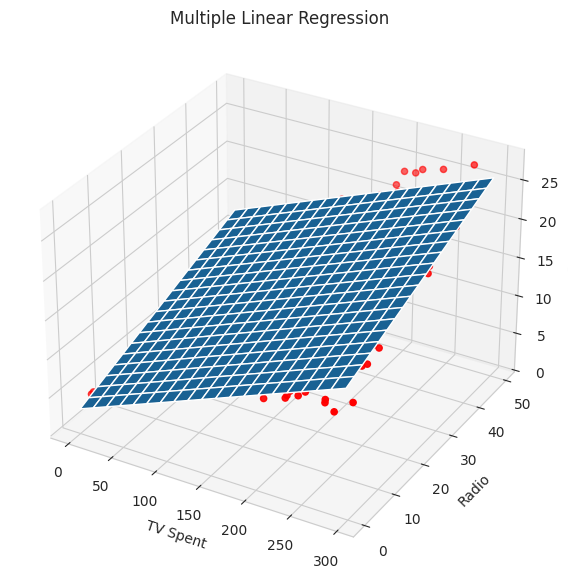

In [65]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111,projection = '3d')
ax.scatter(data['TV'],data['Radio'],Y,color = 'Red')

TV_range = np.linspace(data['TV'].min(), data['TV'].max(), 20)
Radio_range = np.linspace(data['Radio'].min(), data['Radio'].max(), 20)

TV_grid, Radio_grid = np.meshgrid(TV_range,Radio_range)

sales_pred = model.predict(np.c_[TV_grid.ravel(),Radio_grid.ravel()])  # Predict Sales for every location

sales_pred = sales_pred.reshape(TV_grid.shape)

ax.plot_surface(TV_grid,Radio_grid,sales_pred)   # Draw the regression plane

ax.set_xlabel('TV Spent')
ax.set_ylabel('Radio')
ax.set_zlabel('Sales')
plt.title("Multiple Linear Regression")
plt.show()

Interpreting the Graph

- Red dots = Actual data. Each red point is one observation from dataset (TV Spending, Radio Spending, Actual Sales)

- Blue plane = Model predictions. The blue surface is generated from regression equation.

In [66]:
# I'm spending $100 for TV ads and $30 for Radio ads. Predict my sales

In [67]:
model.predict([[100,30]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([13.22110338])

------------------------------------------------------------------------xxxxxxxxxx --------------------------------------------------
